# Ejercicion de programación - Regresión Logistica



In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [35]:

ruta_archivo = '/content/drive/MyDrive/SIS420/datasets/creditcard.csv'

df = pd.read_csv(ruta_archivo)

print("\n Estadísticas del Dataset")
print(f"Total de ejemplos: {len(df)}")
print(f"Número de características: {len(df.columns)-1}")
print(f"\nValores nulos por columna:\n{df.isnull().sum()}")

X = df.drop('Class', axis=1).values
y = df['Class'].values

# Normalizar características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en entrenamiento
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\n División de Datos ")
print(f"Entrenamiento: {len(X_train)} ejemplos")
print(f"Prueba: {len(X_test)} ejemplos")

m_train, n_train = X_train.shape
X_train = np.concatenate([np.ones((m_train, 1)), X_train], axis=1)

m_test, n_test = X_test.shape
X_test = np.concatenate([np.ones((m_test, 1)), X_test], axis=1)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")




 Estadísticas del Dataset
Total de ejemplos: 284807
Número de características: 30

Valores nulos por columna:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

 División de Datos 
Entrenamiento: 227845 ejemplos
Prueba: 56962 ejemplos
Dimensiones de X_train: (227845, 31)
Dimensiones de X_test: (56962, 31)


In [36]:

# FUNCIONES DEL MODELO

def sigmoid(z):

    z = np.array(z)
    return 1 / (1 + np.exp(-z))

def costFunction(theta, X, y):

    m = y.size
    h = sigmoid(X.dot(theta))

    J = (1 / m) * np.sum(-y * np.log(h + 1e-15) - (1 - y) * np.log(1 - h + 1e-15))

    grad = (1 / m) * (h - y).dot(X)

    return J, grad

def predict(theta, X):
    return np.round(sigmoid(X.dot(theta)))



In [37]:
# ENTRENAMIENTO

initial_theta = np.zeros(X_train.shape[1])

options = {'maxiter': 1000}

res = optimize.minimize(
    costFunction,
    initial_theta,
    (X_train, y_train),
    jac=True,
    method='TNC',
    options=options
)

theta_opt = res.x
cost_opt = res.fun

print(f"\n--- Resultados del Entrenamiento ---")
print(f"Costo final: {cost_opt:.4f}")
print(f"Theta optimizado: {theta_opt[:5]}")



/tmp/ipykernel_667/3055029394.py:7: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(



--- Resultados del Entrenamiento ---
Costo final: 0.0038
Theta optimizado: [-8.68641543 -0.35170891  0.26873079 -0.04160281 -0.08380764]


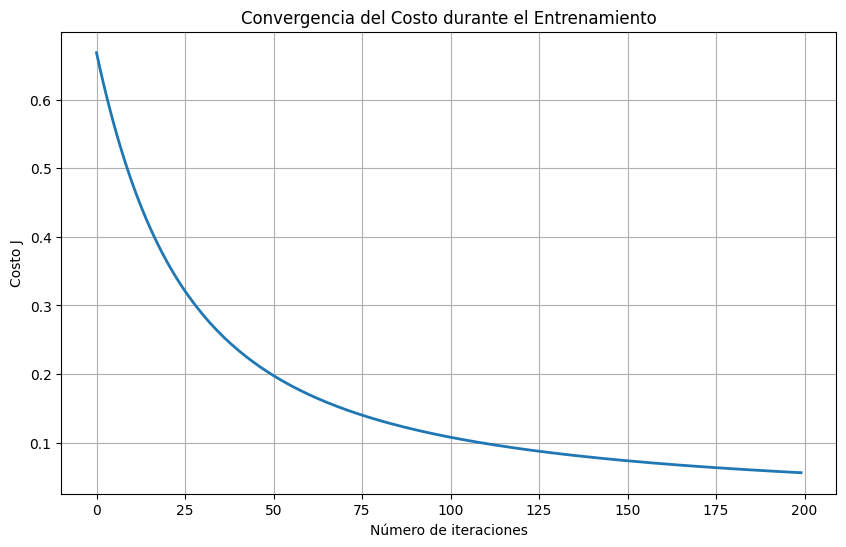

In [38]:

# GRÁFICO DE COSTO

def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(costFunction(theta, X, y)[0])

    return theta, J_history


alpha = 0.1
num_iters = 200
theta_gd, J_history = descensoGradiente(
    initial_theta, X_train, y_train, alpha, num_iters
)


plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del Costo durante el Entrenamiento')
plt.grid(True)
plt.show()



In [39]:
# EVALUACIÓN DEL MODELO

# Predicciones en entrenamiento
p_train = predict(theta_opt, X_train)
accuracy_train = np.mean(p_train == y_train) * 100

# Predicciones en prueba
p_test = predict(theta_opt, X_test)
accuracy_test = np.mean(p_test == y_test) * 100

print(f"\n Evaluación del Modelo ")
print(f"Precisión en entrenamiento (80%): {accuracy_train:.2f}%")
print(f"Precisión en prueba (20%): {accuracy_test:.2f}%")




 Evaluación del Modelo 
Precisión en entrenamiento (80%): 99.92%
Precisión en prueba (20%): 99.91%


In [40]:
#EJEMPLOS DE PREDICCIONES

print(f"\n Ejemplos de Predicciones (primeros 10 de prueba) ")
for i in range(10):
    prob = sigmoid(np.dot(X_test[i], theta_opt))
    pred = 1 if prob >= 0.5 else 0
    print(f"Ejemplo {i+1}: Real={y_test[i]}, Predicción={pred}, Probabilidad={prob:.4f}")




 Ejemplos de Predicciones (primeros 10 de prueba) 
Ejemplo 1: Real=1, Predicción=1, Probabilidad=1.0000
Ejemplo 2: Real=0, Predicción=0, Probabilidad=0.0001
Ejemplo 3: Real=0, Predicción=0, Probabilidad=0.0001
Ejemplo 4: Real=0, Predicción=0, Probabilidad=0.0007
Ejemplo 5: Real=0, Predicción=0, Probabilidad=0.0001
Ejemplo 6: Real=0, Predicción=0, Probabilidad=0.0001
Ejemplo 7: Real=0, Predicción=0, Probabilidad=0.0001
Ejemplo 8: Real=0, Predicción=0, Probabilidad=0.0002
Ejemplo 9: Real=0, Predicción=0, Probabilidad=0.0007
Ejemplo 10: Real=0, Predicción=0, Probabilidad=0.0008
